# Module 07 Lab - Better Model Evaluation

**Objective:** To move beyond simple accuracy and learn how to use more sophisticated and reliable evaluation techniques, including the confusion matrix, precision, recall, and cross-validation.

**In this lab, you will write the code to generate and interpret these advanced evaluation metrics.**

## Part 1: Setup and Model Training

Let's first train a model so we have something to evaluate. We will use the Titanic dataset again to predict survival.

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Load and prepare data
df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
# Explicitly filling missing Age values to ensure the model receives a complete dataset, as Logistic Regression requires zero NaN inputs.
df['Age'] = df['Age'].fillna(df['Age'].median())

features = ['Age', 'Pclass', 'Sex', 'Fare']
target = 'Survived'

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

## Part 2: The Confusion Matrix

**Concept:** A confusion matrix gives you a more detailed breakdown of a model's performance than accuracy alone. It's a table that shows you where your model got things right and where it got them wrong.

It has four quadrants:
*   **True Positives (TP):** Correctly predicted positive (e.g., predicted survival, and they did survive).
*   **True Negatives (TN):** Correctly predicted negative (e.g., predicted did not survive, and they did not).
*   **False Positives (FP):** Incorrectly predicted positive (e.g., predicted survival, but they did not). Also called a "Type I Error".
*   **False Negatives (FN):** Incorrectly predicted negative (e.g., predicted did not survive, but they did). Also called a "Type II Error".

### Task 1: Generate and Plot a Confusion Matrix

**Your Task:** Use `confusion_matrix` from `sklearn.metrics` to calculate the matrix and `seaborn.heatmap` to visualize it.

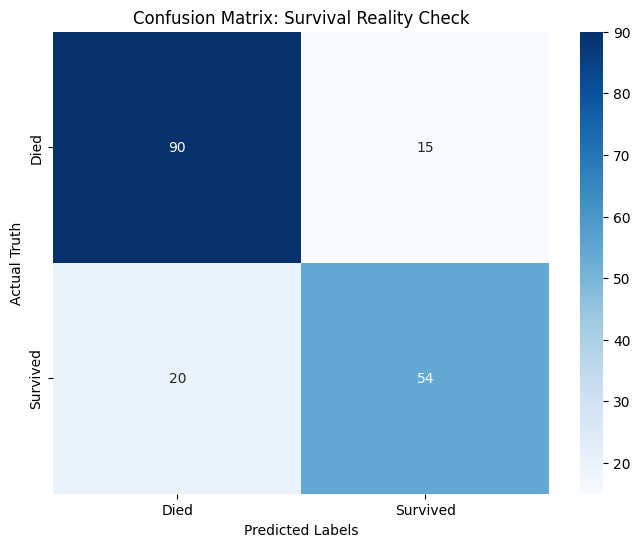

Correctly predicted as Died (TN): 90
Incorrectly predicted as Survived (FP/Type I Error): 15
Incorrectly predicted as Died (FN/Type II Error): 20
Correctly predicted as Survived (TP): 54


In [3]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# --- Task 1: Generate and Plot a Confusion Matrix ---

# 1. Calculate the confusion matrix using the actual values and your predictions
cm = confusion_matrix(y_test, y_pred)

# 2. Create a heatmap to visualize it
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Died', 'Survived'], 
            yticklabels=['Died', 'Survived'])

plt.xlabel('Predicted Labels')
plt.ylabel('Actual Truth')
plt.title('Confusion Matrix: Survival Reality Check')
plt.show()

# Quick interpretation of the "Truth"
print(f"Correctly predicted as Died (TN): {cm[0,0]}")
print(f"Incorrectly predicted as Survived (FP/Type I Error): {cm[0,1]}")
print(f"Incorrectly predicted as Died (FN/Type II Error): {cm[1,0]}")
print(f"Correctly predicted as Survived (TP): {cm[1,1]}")

## Part 3: Precision, Recall, and F1-Score

**Concept:** From the confusion matrix, we can calculate more nuanced metrics:

*   **Precision:** Of all the times the model predicted **positive**, how often was it correct? 
    *   Formula: `TP / (TP + FP)`
    *   *Use Case:* When the cost of a **False Positive** is high. (e.g., a spam filter; you don't want to incorrectly mark an important email as spam).

*   **Recall (Sensitivity):** Of all the actual **positives**, how many did the model correctly identify?
    *   Formula: `TP / (TP + FN)`
    *   *Use Case:* When the cost of a **False Negative** is high. (e.g., a medical test for a serious disease; you don't want to miss a real case).

*   **F1-Score:** The harmonic mean of Precision and Recall. It provides a single score that balances both.

### Task 2: Generate a Classification Report

**Your Task:** Use `classification_report` from `sklearn.metrics` to get a summary of these metrics for each class.

In [4]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Calculate metrics
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Precision (Reliability): {precision:.2%}")
print(f"Recall (Search Efficiency): {recall:.2%}")
print(f"F1-Score (The Balance): {f1:.2%}")

Precision (Reliability): 78.26%
Recall (Search Efficiency): 72.97%
F1-Score (The Balance): 75.52%


## Part 4: Cross-Validation

**Concept:** A single train-test split can be lucky or unlucky. What if, by chance, all the "easy" examples ended up in our test set? Our accuracy score would be misleadingly high.

**Cross-Validation (CV)** solves this. It splits the data into multiple "folds" (e.g., 5 or 10). It then trains and evaluates the model multiple times, using a different fold as the test set each time. The final score is the average of the scores from all folds.

This gives a much more robust and reliable estimate of the model's true performance.

### Task 3: Perform Cross-Validation

**Your Task:** Use `cross_val_score` from `sklearn.model_selection` to perform 5-fold cross-validation on your model.

In [5]:
from sklearn.model_selection import cross_val_score

# 1. Perform 5-fold cross-validation
# We use the entire dataset (X, y) because CV handles the internal splitting for us.
cv_scores = cross_val_score(model, X, y, cv=5)

# 2. Print the scores for each fold and the average score
print(f"Scores for each fold: {cv_scores}")
print(f"Average CV Score: {cv_scores.mean():.2%}")
print(f"Standard Deviation of CV Scores: {cv_scores.std():.4f}")

Scores for each fold: [0.7877095  0.78089888 0.78651685 0.7752809  0.80337079]
Average CV Score: 78.68%
Standard Deviation of CV Scores: 0.0094


## 📝 Knowledge Check

**Instructions:** Answer the following questions in this markdown cell.


1. Describe a real-world scenario where you would care more about a model's Precision than its Recall.
The Scenario: Identifying Prohibited Ingredients (Peanut Allergy / Haram).

The Reasoning: In this scenario, a False Positive, the AI says "This is Peanut-Free" or "This is Halal," but it actually contains peanuts or pork, is a catastrophic failure that can lead to medical emergencies or religious violation.

Precision Priority: We need high Precision because we want to be absolutely certain that when the AI labels something as "Safe", Positive, it is 100% correct. It is better for the AI to be uncertain and ask for human verification than to give a "False Truth" that causes harm.

2. Describe a real-world scenario where you would care more about a model's Recall than its Precision.
The Scenario: Processing Safety Recalls (Salmonella/Contamination).

The Reasoning: In the case of a poisonous hazard or an FDA recall, a False Negative, the AI misses a contaminated item and lets it through to the customer is the primary danger.

Recall Priority: We care more about Recall, Sensitivity, here because we want to "catch" every single instance of the hazard. We would rather have the AI be "over-protective" and accidentally flag safe lettuce, False Positive, than miss a single batch of contaminated lettuce that could cause death.

3. Why is a cross-validation score generally more trustworthy than a score from a single train-test split?
The Reasoning: A single train-test split is highly susceptible to sampling bias, often referred to as "the luck of the draw." If a random split happens to place only straightforward or repetitive examples into the test set, the resulting accuracy score may be artificially high. This creates a misleading narrative of the model’s performance that might not hold up when the AI encounters a more diverse or complex real-world inventory.

The Cross-Validation Advantage: Cross-validation (CV) provides a more robust and stable evaluation by rotating the test set through multiple "folds" of the data. Instead of relying on one potentially "lucky" split, the model is tested several times against different subsets of the entire dataset. By averaging these scores, we obtain a more accurate measure of the model's true predictive power. For the ShoppinAI project, this ensures that the safety logic is consistent and reliable across a wide range of product categories and store brands, rather than being a fluke of a single data split.